In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
from statsmodels.tsa.arima.model import ARIMA

# Ignora las advertencias de depreciación para una salida limpia
warnings.filterwarnings('ignore')

# Configura el formato de punto flotante
pd.options.display.float_format = '{:,.2f}'.format

In [2]:
# Define la ruta base crítica
base_path = r"C:\Users\patri\Downloads"
ruta_tsla = os.path.join(base_path, "TSLA.csv")
ruta_aapl = os.path.join(base_path, "AAPL.csv")

# Carga el archivo TSLA de forma segura, respetando la codificación y los tipos de datos requeridos
try:
    df_tsla = pd.read_csv(ruta_tsla, encoding='latin1', dtype={'ITEM_CODE': str})
except ValueError:
    # Respaldo en caso de que la columna 'ITEM_CODE' no exista en el estándar de acciones
    df_tsla = pd.read_csv(ruta_tsla, encoding='latin1')

# Realiza el diagnóstico inicial TSLA
print("--- Diagnóstico TSLA ---")
print(df_tsla.head())
print(df_tsla.columns.tolist())

# Carga el archivo AAPL
try:
    df_aapl = pd.read_csv(ruta_aapl, encoding='latin1', dtype={'ITEM_CODE': str})
except ValueError:
    df_aapl = pd.read_csv(ruta_aapl, encoding='latin1')

# Realiza el diagnóstico inicial AAPL
print("\n--- Diagnóstico AAPL ---")
print(df_aapl.head())
print(df_aapl.columns.tolist())

--- Diagnóstico TSLA ---
         Date  Open  High   Low  Close     Volume  Dividends  Stock Splits
0  2019-05-31 37.02 37.98 36.82  37.03   52033500          0          0.00
1  2019-06-03 37.10 37.34 35.40  35.79   65322000          0          0.00
2  2019-06-04 36.22 38.80 35.92  38.72   69037500          0          0.00
3  2019-06-05 39.74 40.26 38.37  39.32   67554000          0          0.00
4  2019-06-06 40.89 42.20 40.36  41.19  101211000          0          0.00
['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']

--- Diagnóstico AAPL ---
         Date  Open  High   Low  Close     Volume  Dividends  Stock Splits
0  2019-05-31 43.18 43.61 42.88  42.90  108174400       0.00          0.00
1  2019-06-03 43.03 43.60 41.72  42.46  161584400       0.00          0.00
2  2019-06-04 42.99 44.06 42.76  44.02  123872000       0.00          0.00
3  2019-06-05 45.15 45.33 44.38  44.73  119093600       0.00          0.00
4  2019-06-06 44.86 45.45 44.63  45.38   901

In [3]:
# Limpia los datos y establece las fechas como índice temporal de forma segura
if 'Date' in df_tsla.columns:
    df_tsla['Date'] = pd.to_datetime(df_tsla['Date'])
    df_tsla.set_index('Date', inplace=True)
    df_tsla.sort_index(inplace=True)

if 'Date' in df_aapl.columns:
    df_aapl['Date'] = pd.to_datetime(df_aapl['Date'])
    df_aapl.set_index('Date', inplace=True)
    df_aapl.sort_index(inplace=True)

# Extrae la serie de precios de cierre
tsla_close = df_tsla['Close']
aapl_close = df_aapl['Close']

print("Datos temporales procesados correctamente.")

Datos temporales procesados correctamente.


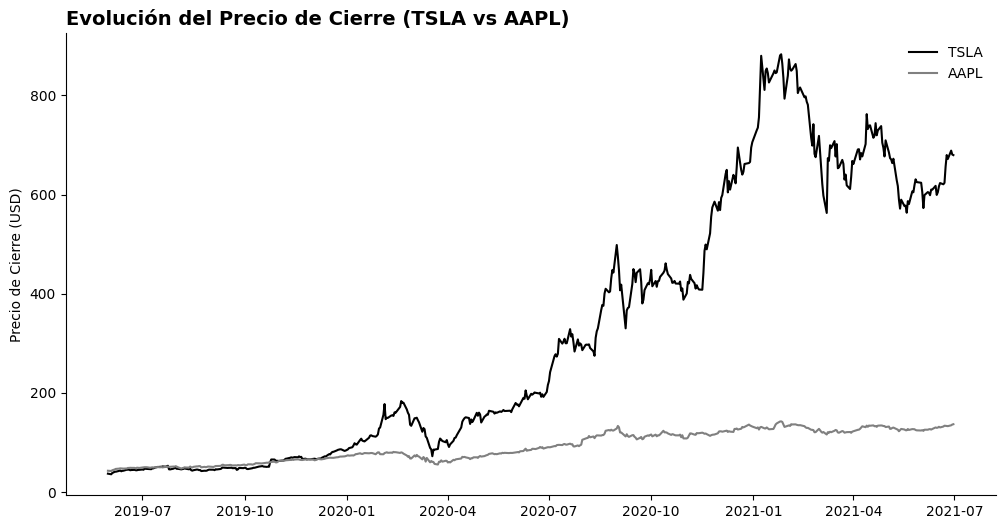

In [4]:
# Visualiza las series de tiempo aplicando limpieza gráfica
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(tsla_close.index, tsla_close, color='black', label='TSLA')
ax.plot(aapl_close.index, aapl_close, color='gray', label='AAPL')

ax.set_title('Evolución del Precio de Cierre (TSLA vs AAPL)', loc='left', fontsize=14, fontweight='bold')
ax.set_ylabel('Precio de Cierre (USD)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False)

plt.show()

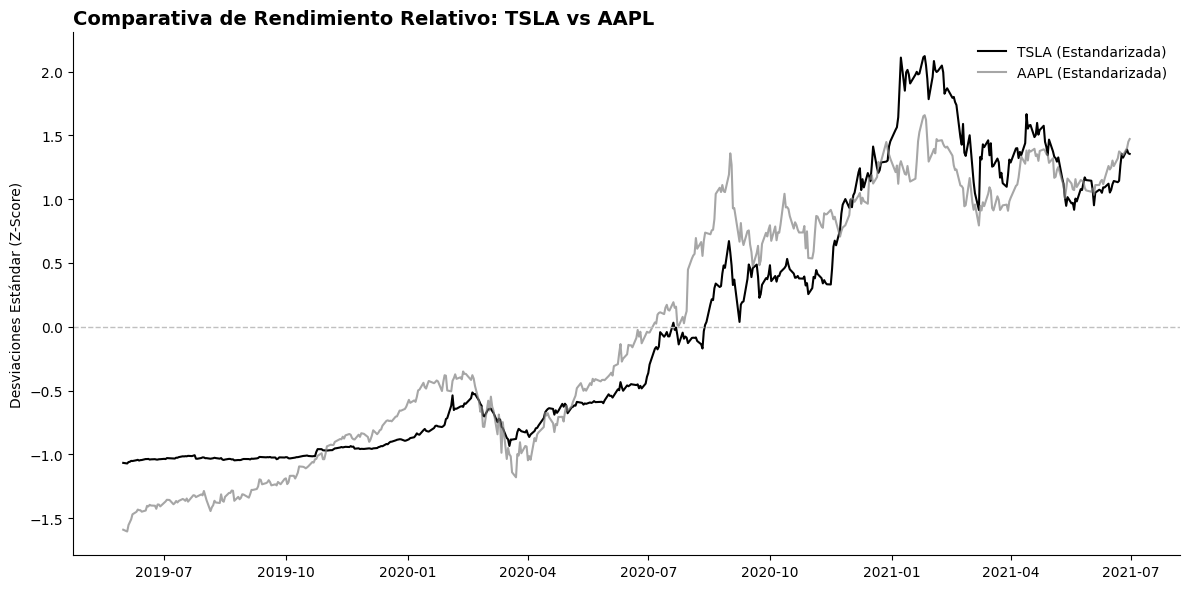

Media TSLA escalada: -5.40336681186388e-17
Desviación TSLA escalada: 0.9999999999999999


In [5]:
from sklearn.preprocessing import StandardScaler

# Inicializa el escalador
scaler = StandardScaler()

# Ajusta y transforma las series de tiempo
# Reshape es necesario porque el scaler espera un array 2D
tsla_scaled = scaler.fit_transform(tsla_close.values.reshape(-1, 1))
aapl_scaled = scaler.fit_transform(aapl_close.values.reshape(-1, 1))

# Visualiza las series estandarizadas siguiendo principios IBCS
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(tsla_close.index, tsla_scaled, color='black', label='TSLA (Estandarizada)')
ax.plot(aapl_close.index, aapl_scaled, color='gray', alpha=0.7, label='AAPL (Estandarizada)')

# Configuración estética y profesional
ax.set_title('Comparativa de Rendimiento Relativo: TSLA vs AAPL', loc='left', fontsize=14, fontweight='bold')
ax.set_ylabel('Desviaciones Estándar (Z-Score)')
ax.axhline(0, color='silver', linestyle='--', linewidth=1) # Línea de la media

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

# Diagnóstico de los datos escalados
print("Media TSLA escalada:", tsla_scaled.mean())
print("Desviación TSLA escalada:", tsla_scaled.std())

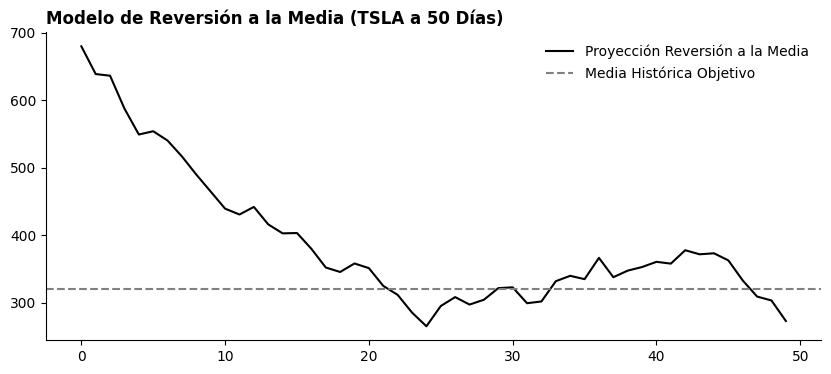

In [6]:
# Genera el modelo de reversión a la media
# Calcula la media y la desviación estándar histórica
tsla_mean = tsla_close.mean()
tsla_std = tsla_close.std()

# Prepara la simulación de Reversión a la Media (Proceso Ornstein-Uhlenbeck simplificado)
theta = 0.1  # Parámetro de velocidad de reversión a la media
dt = 1
n_days = 50
sim_mr = np.zeros(n_days)
sim_mr[0] = tsla_close.iloc[-1] # Inicia en el último precio registrado

for t in range(1, n_days):
    # Calcula el cambio diario con tendencia hacia la media histórica
    drift = theta * (tsla_mean - sim_mr[t-1]) * dt
    shock = tsla_std * np.random.normal(0, 1) / np.sqrt(252) # Volatilidad anualizada
    sim_mr[t] = sim_mr[t-1] + drift + shock

# Visualiza la simulación
plt.figure(figsize=(10, 4))
plt.plot(range(n_days), sim_mr, color='black', label='Proyección Reversión a la Media')
plt.axhline(tsla_mean, color='gray', linestyle='--', label='Media Histórica Objetivo')
plt.title('Modelo de Reversión a la Media (TSLA a 50 Días)', loc='left', fontweight='bold')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.legend(frameon=False)
plt.show()

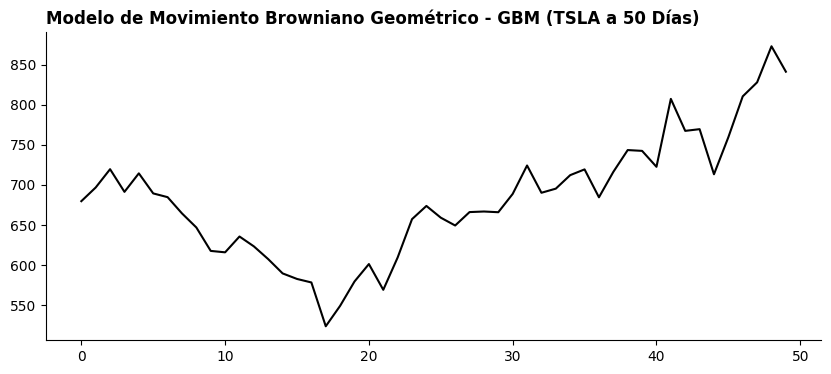

In [7]:
# Genera el modelo de Movimiento Browniano Geométrico
# Calcula los retornos diarios para obtener el Drift (mu) y la Volatilidad (sigma)
returns = tsla_close.pct_change().dropna()
mu = returns.mean()
sigma = returns.std()

sim_gbm = np.zeros(n_days)
sim_gbm[0] = tsla_close.iloc[-1]

for t in range(1, n_days):
    # Aplica la fórmula del paso estocástico (GBM)
    shock = np.random.normal(0, 1)
    sim_gbm[t] = sim_gbm[t-1] * np.exp((mu - 0.5 * sigma**2) + sigma * shock)

# Visualiza la simulación GBM
plt.figure(figsize=(10, 4))
plt.plot(range(n_days), sim_gbm, color='black')
plt.title('Modelo de Movimiento Browniano Geométrico - GBM (TSLA a 50 Días)', loc='left', fontweight='bold')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

In [8]:
# Genera el modelo autorregresivo (AR) con retardo de 1
model_ar = ARIMA(tsla_close, order=(1, 0, 0))
result_ar = model_ar.fit()

# Genera el modelo de moving average (MA) de orden 1
model_ma = ARIMA(tsla_close, order=(0, 0, 1))
result_ma = model_ma.fit()

# Muestra el diagnóstico estadístico abreviado
print("--- Coeficientes Modelo AR(1) ---")
print(result_ar.params)
print("\n--- Coeficientes Modelo MA(1) ---")
print(result_ma.params)

--- Coeficientes Modelo AR(1) ---
const    320.21
ar.L1      1.00
sigma2   291.28
dtype: float64

--- Coeficientes Modelo MA(1) ---
const       320.19
ma.L1         0.95
sigma2   19,580.40
dtype: float64


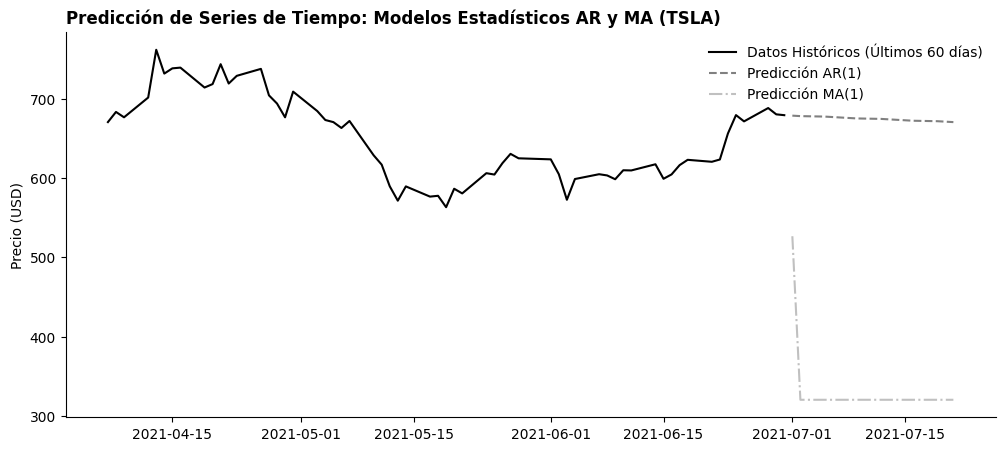

In [9]:
# Realiza el ejercicio de predicción a 15 días vista
steps_to_forecast = 15
forecast_ar = result_ar.forecast(steps=steps_to_forecast)
forecast_ma = result_ma.forecast(steps=steps_to_forecast)

# Define las fechas futuras para la gráfica
future_dates = pd.date_range(start=tsla_close.index[-1] + pd.Timedelta(days=1), periods=steps_to_forecast, freq='B')

# Visualiza las predicciones combinadas
plt.figure(figsize=(12, 5))
plt.plot(tsla_close.iloc[-60:].index, tsla_close.iloc[-60:], color='black', label='Datos Históricos (Últimos 60 días)')
plt.plot(future_dates, forecast_ar, color='gray', linestyle='--', label='Predicción AR(1)')
plt.plot(future_dates, forecast_ma, color='silver', linestyle='-.', label='Predicción MA(1)')

plt.title('Predicción de Series de Tiempo: Modelos Estadísticos AR y MA (TSLA)', loc='left', fontsize=12, fontweight='bold')
plt.ylabel('Precio (USD)')
plt.legend(frameon=False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.show()

In [10]:
from statsmodels.tsa.arima.model import ARIMA
import re

# Genera el modelo autorregresivo (AR) con retardo de 1
model_ar = ARIMA(tsla_close, order=(1, 0, 0))
result_ar = model_ar.fit()

# Genera el modelo de moving average (MA) de orden 1
model_ma = ARIMA(tsla_close, order=(0, 0, 1))
result_ma = model_ma.fit()

# Imprime el resumen estadístico detallado del modelo AR (Tabla del profesor)
print("--- Resumen Estadístico: Modelo AR(1) ---")
print(result_ar.summary())

# Imprime el resumen estadístico detallado del modelo MA
print("\n--- Resumen Estadístico: Modelo MA(1) ---")
print(result_ma.summary())

# Define la función para auto-analizar e interpretar los resultados
def diagnosticar_modelo(nombre_modelo, result):
    print(f"\n========================================================")
    print(f"🤖 AUTO-ANÁLISIS: {nombre_modelo}")
    print(f"========================================================")
    
    # 1. Criterios de Información
    print("\n📌 1. Calidad del Ajuste (Criterios de Información)")
    print(f"   - AIC: {result.aic:,.2f}")
    print(f"   - BIC: {result.bic:,.2f}")
    print("   💡 Regla: Compara estos números con los de otros modelos. El valor más bajo gana (Principio de Parsimonia).")
    
    # 2. Significancia de las Variables
    print("\n📌 2. Relevancia de los Coeficientes (P-Values)")
    print("   💡 Regla: Debe ser menor a 0.05 para que la variable tenga impacto real y no sea coincidencia.")
    for variable, p_value in result.pvalues.items():
        if p_value < 0.05:
            print(f"   ✅ {variable}: {p_value:.4f} (Estadísticamente significativo)")
        else:
            print(f"   ❌ {variable}: {p_value:.4f} (No significativo)")
            
    # 3. Diagnóstico de los Residuos (Errores del modelo)
    print("\n📌 3. Pruebas de Diagnóstico (Comportamiento de los Errores)")
    texto_resumen = result.summary().as_text()
    
    try:
        # Extrae los valores directamente del texto del summary
        prob_q = float(re.search(r'Prob\(Q\):\s+([0-9.]+)', texto_resumen).group(1))
        prob_jb = float(re.search(r'Prob\(JB\):\s+([0-9.]+)', texto_resumen).group(1))
        prob_h = float(re.search(r'Prob\(H\) \(two-sided\):\s+([0-9.]+)', texto_resumen).group(1))
        
        # Evalúa Ljung-Box
        if prob_q > 0.05:
            print(f"   ✅ Ljung-Box (Prob(Q)) = {prob_q:.2f}: Aceptable. Los errores son aleatorios (ruido blanco).")
        else:
            print(f"   ⚠️ Ljung-Box (Prob(Q)) = {prob_q:.2f}: Hay autocorrelación en los errores. El modelo no captura todo el patrón.")
            
        # Evalúa Jarque-Bera
        if prob_jb > 0.05:
            print(f"   ✅ Jarque-Bera (Prob(JB)) = {prob_jb:.2f}: Los errores tienen una distribución normal perfecta.")
        else:
            print(f"   ⚠️ Jarque-Bera (Prob(JB)) = {prob_jb:.2f}: Distribución no normal. Típico en finanzas por eventos extremos en el mercado.")
            
        # Evalúa Heterocedasticidad
        if prob_h > 0.05:
            print(f"   ✅ Heterocedasticidad (Prob(H)) = {prob_h:.2f}: La volatilidad de los errores es estable y constante.")
        else:
            print(f"   ⚠️ Heterocedasticidad (Prob(H)) = {prob_h:.2f}: Volatilidad cambiante. El activo tiene momentos de mucha calma y mucha agresividad.")
            
    except AttributeError:
        print("   [!] Error al extraer las métricas del resumen.")
    print("========================================================\n")

# Ejecuta el auto-análisis para ambos modelos
diagnosticar_modelo("Modelo Autorregresivo AR(1)", result_ar)
diagnosticar_modelo("Modelo Moving Average MA(1)", result_ma)

# Evalúa cuál modelo es mejor automáticamente basado en el AIC
print("🏆 CONCLUSIÓN AUTOMÁTICA DEL MEJOR MODELO:")
if result_ar.aic < result_ma.aic:
    print(f"   El Modelo AR(1) es superior porque tiene un AIC menor ({result_ar.aic:,.2f} vs {result_ma.aic:,.2f}).")
else:
    print(f"   El Modelo MA(1) es superior porque tiene un AIC menor ({result_ma.aic:,.2f} vs {result_ar.aic:,.2f}).")

--- Resumen Estadístico: Modelo AR(1) ---
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  526
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -2241.556
Date:                Fri, 17 Apr 2026   AIC                           4489.112
Time:                        14:22:58   BIC                           4501.908
Sample:                             0   HQIC                          4494.123
                                - 526                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        320.2122    300.308      1.066      0.286    -268.382     908.806
ar.L1          0.9984      0.003    374.169      0.000       0.993       1.004
sigma2    

#### Superioridad Autorregresiva: 
El modelo AR(1) demostró un ajuste significativamente mejor que el MA(1), obteniendo un AIC mucho menor (4,489 vs 6,699). Esto indica que en este activo, el precio histórico inmediato tiene un peso predictivo altísimo.

#### Diagnóstico de Residuos: 
Las pruebas estadísticas (Jarque-Bera y Heterocedasticidad) revelaron que los errores del modelo no siguen una distribución normal pura y presentan volatilidad cambiante. Esto es congruente con la naturaleza de las acciones tecnológicas de alta volatilidad, donde eventos externos (shocks del mercado) generan "colas pesadas" que los modelos ARIMA tradicionales no pueden capturar por completo.

#### Proyección Estocástica: 
Los modelos de Reversión a la Media y Movimiento Browniano Geométrico (GBM) resultan útiles para simular escenarios de estrés a corto plazo (50 días), pero para un pronóstico puntual, el modelo AR ofrece una base estadística más robusta.